In [1]:
import os
import datetime
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import colorcet as cc
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import pandas as pd
from bokeh.plotting import figure, output_notebook, show
from bokeh.models import HoverTool, Title
from pathlib import Path
import folium
import rioxarray
import netCDF4

from shapely.geometry import box

from blackmarble.extract import bm_extract
from blackmarble.raster import bm_raster

import xarray as xr
import numpy as np

#Local Functions
import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box, mask_dataset_by_geometry

#Settings
%load_ext autoreload
%autoreload 2

plt.rcParams["figure.figsize"] = (18, 10)
pd.set_option('display.max_rows', 50)

In [2]:
# Define a list of color hex codes or names (from low to high)
color_list = ["#6666cc", "#aa66cc", "#ee99ee", "#ffb366", "#ffff99", 
             #"#FFFFFF"
             ]

# Create a colormap from that list
NTL_cmap = mcolors.LinearSegmentedColormap.from_list("my_colormap", color_list).reversed()

In [3]:
somaliland_shp = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)
SL_Berbera_VNP46A4_EY_2012_24 = xr.open_dataset("../data/NTL_Data_A4/SL_Berbera_VNP46A4_EY_2012_24.nc")
SL_Berbera_VNP46A4_EY_2012_24 = SL_Berbera_VNP46A4_EY_2012_24.where(SL_Berbera_VNP46A4_EY_2012_24 != 6553.5, 0)

logged_NTL = xr.where(
    SL_Berbera_VNP46A4_EY_2012_24 > 0, 
    np.log(SL_Berbera_VNP46A4_EY_2012_24), 
    0  # Assign 0 for non-positive values
)

logged_NTL = mask_dataset_by_geometry(logged_NTL, somaliland_shp)

C:\Users\samsa\anaconda3\Lib\site-packages\xarray\core\computation.py:761: RuntimeWarning: divide by zero encountered in log
  result_data = func(*input_data)


In [4]:
#Regions
maroodi_jeex = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Maroodi Jeex"]), somaliland_shp[somaliland_shp["admin1Name"]== "Maroodi Jeex"])
togdheer = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Togdheer"]), somaliland_shp[somaliland_shp["admin1Name"]== "Togdheer"])
awdal = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Awdal"]), somaliland_shp[somaliland_shp["admin1Name"]== "Awdal"])
sool = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Sool"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sool"])
sanaag = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Sanaag"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sanaag"])
sahil = filter_dataset_by_bounding_box(mask_dataset_by_geometry(SL_Berbera_VNP46A4_EY_2012_24, somaliland_shp[somaliland_shp["admin1Name"]=="Sahil"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sahil"])


logged_maroodi_jeex = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Maroodi Jeex"]), somaliland_shp[somaliland_shp["admin1Name"]== "Maroodi Jeex"])
logged_togdheer = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Togdheer"]), somaliland_shp[somaliland_shp["admin1Name"]== "Togdheer"])
logged_awdal = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Awdal"]), somaliland_shp[somaliland_shp["admin1Name"]== "Awdal"])
logged_sool = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Sool"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sool"])
logged_sanaag = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Sanaag"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sanaag"])
logged_sahil = filter_dataset_by_bounding_box(mask_dataset_by_geometry(logged_NTL, somaliland_shp[somaliland_shp["admin1Name"]=="Sahil"]), somaliland_shp[somaliland_shp["admin1Name"]== "Sahil"])



region_datasets = [
    maroodi_jeex,
    sahil,
    awdal,
    togdheer,
    sanaag,
    sool,
]

log_region_datasets = [
    logged_maroodi_jeex,
    logged_sahil,
    logged_awdal,
    logged_togdheer,
    logged_sanaag,
    logged_sool,
]

region_names = [
    "Maroodi Jeex",
    "Sahil",
    "Awdal",
    "Togdheer",
    "Sanaag",
    "Sool",
]



region_list = dict(zip(region_names, region_datasets))
log_region_list = dict(zip(region_names, log_region_datasets))

all_region_yearly_sums = {}

for region_name, region_data in zip(region_names, region_datasets):
    yearly_sums = []
    for year in range(2012, 2024):
        try:
            value = region_data["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
        except KeyError:
            value = np.nan  # If the date is missing
        yearly_sums.append(round(value, 1))
    all_region_yearly_sums[region_name] = yearly_sums


regions = pd.DataFrame(all_region_yearly_sums)
regions["Year"] = list(range(2012, 2024))
regions = regions[["Year"] + region_names]

regions["Total"] = regions[region_names].sum(axis=1)

In [5]:
#Cities
HGA = gpd.read_file("../data/Combined_Datasets/Hargeisa_shp/HGA.shp")
Berbera = gpd.read_file("../data/Combined_Datasets/Berbera_shp/Berbera.shp")
Burao = gpd.read_file("../data/Combined_Datasets/Burao_shp/Burao.shp")
Boroma = gpd.read_file("../data/Combined_Datasets/Boroma_shp/Boroma.shp")
Erigavo = gpd.read_file("../data/Combined_Datasets/Erigavo_shp/Erigavo.shp")
Las_Anod = gpd.read_file("../data/Combined_Datasets/Las_Anod_shp/Las_Anod.shp")

# For graphing
HGA_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, HGA)
Berbera_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Berbera)
Burao_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Burao)
Boroma_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Boroma)
Erigavo_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Erigavo)
Las_Anod_NTL = filter_dataset_by_bounding_box(SL_Berbera_VNP46A4_EY_2012_24, Las_Anod)

cities_datasets = [HGA_NTL,
          Berbera_NTL,
          Boroma_NTL,
          Burao_NTL,
          Erigavo_NTL,
          Las_Anod_NTL
         ]

cities_names = ["Hargeisa",
                "Berbera",
                "Boroma",
                "Burao",
                "Erigavo",
                "Las Anod"
               ]

all_city_yearly_sums = {}

for city_name, city_data in zip(cities_names, cities_datasets):
    yearly_sums = []
    for year in range(2012, 2024):
        try:
            value = city_data["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01").sum().item()
        except KeyError:
            value = np.nan  # If the date is missing
        yearly_sums.append(round(value, 1))
    all_city_yearly_sums[city_name] = yearly_sums


cities = pd.DataFrame(all_city_yearly_sums)
cities["Year"] = list(range(2012, 2024))
cities = cities[["Year"] + cities_names]
cities["Total Cities"] = cities[cities_names].sum(axis=1)

In [6]:
percentage_city_region = pd.DataFrame()

for i in range(0,6):
    region = list(region_list.keys())[i]
    city_name = cities_names[i]
    percentage_city_region[region] = round(cities[city_name]/regions[region], 3)*100

percentage_city_region["Total"] = round(cities["Total Cities"]/regions["Total"], 3)*100

percentage_city_region["Year"] = list(range(2012, 2024))
percentage_city_region = percentage_city_region[["Year"] + list(percentage_city_region.columns)[:-1]]


percentage_region_total = pd.DataFrame()

for i in range(0,6):
    region = list(region_list.keys())[i]
    percentage_region_total[region] = round(regions[region]/regions["Total"], 3)*100

percentage_region_total["Year"] = list(range(2012, 2024))
percentage_region_total = percentage_region_total[["Year"] + list(percentage_region_total.columns)[:-1]]

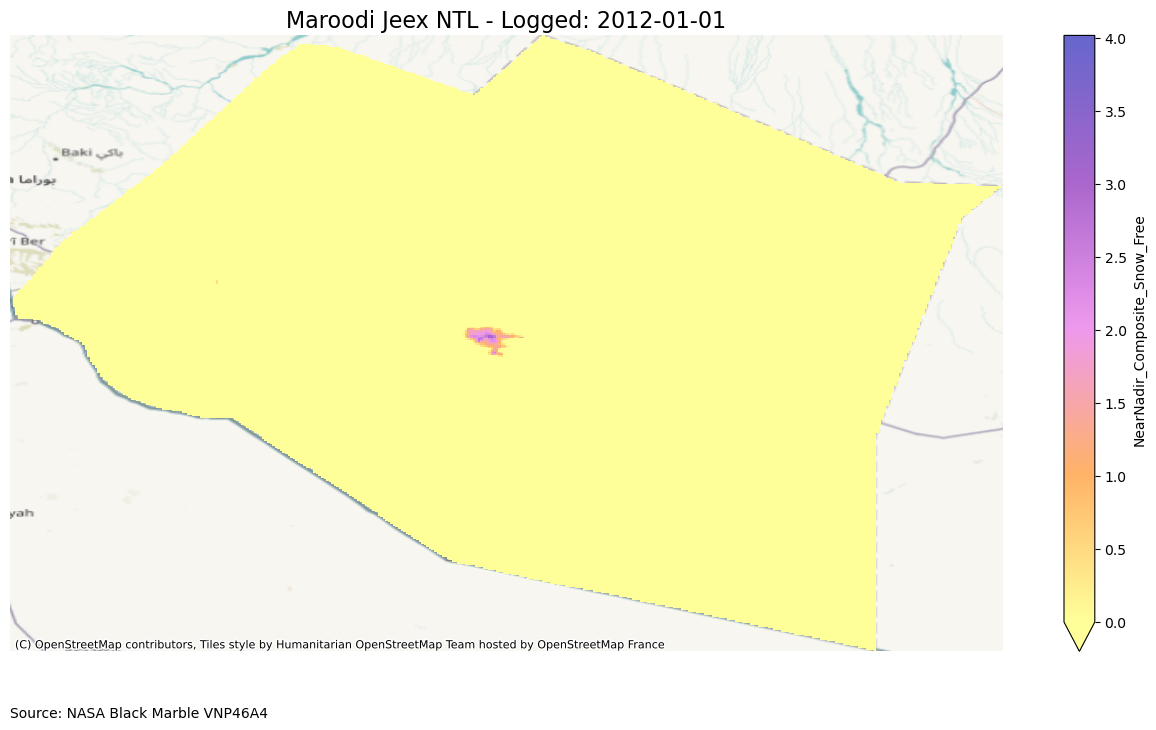

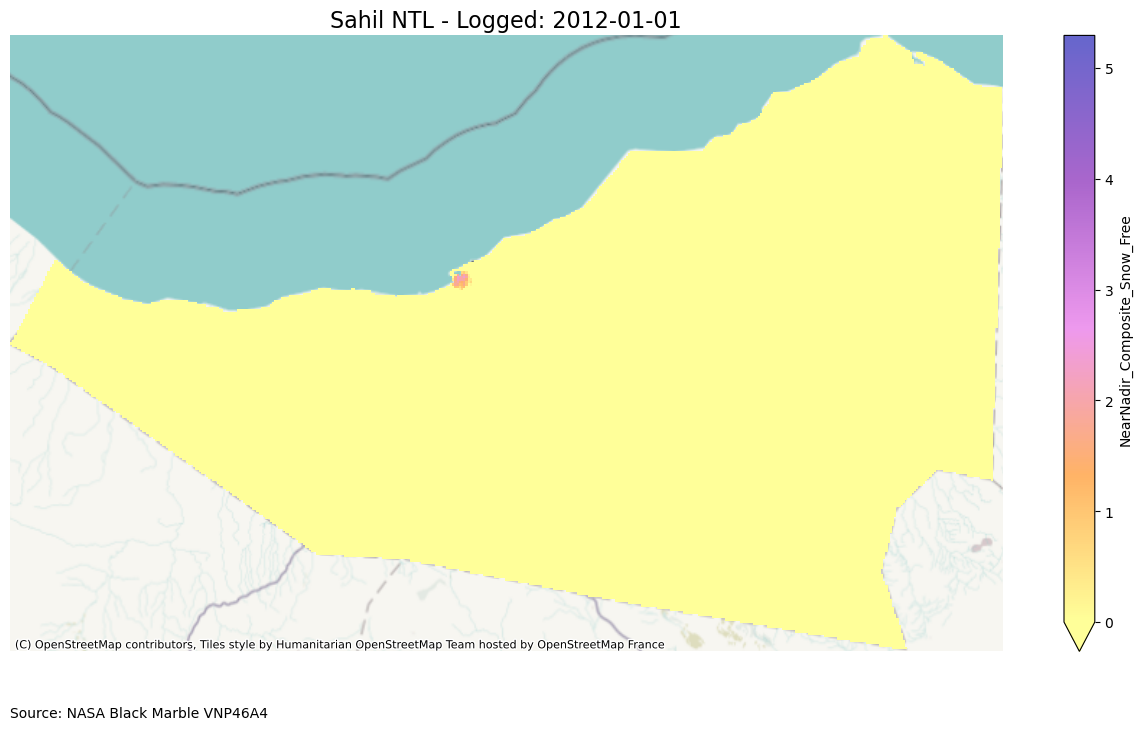

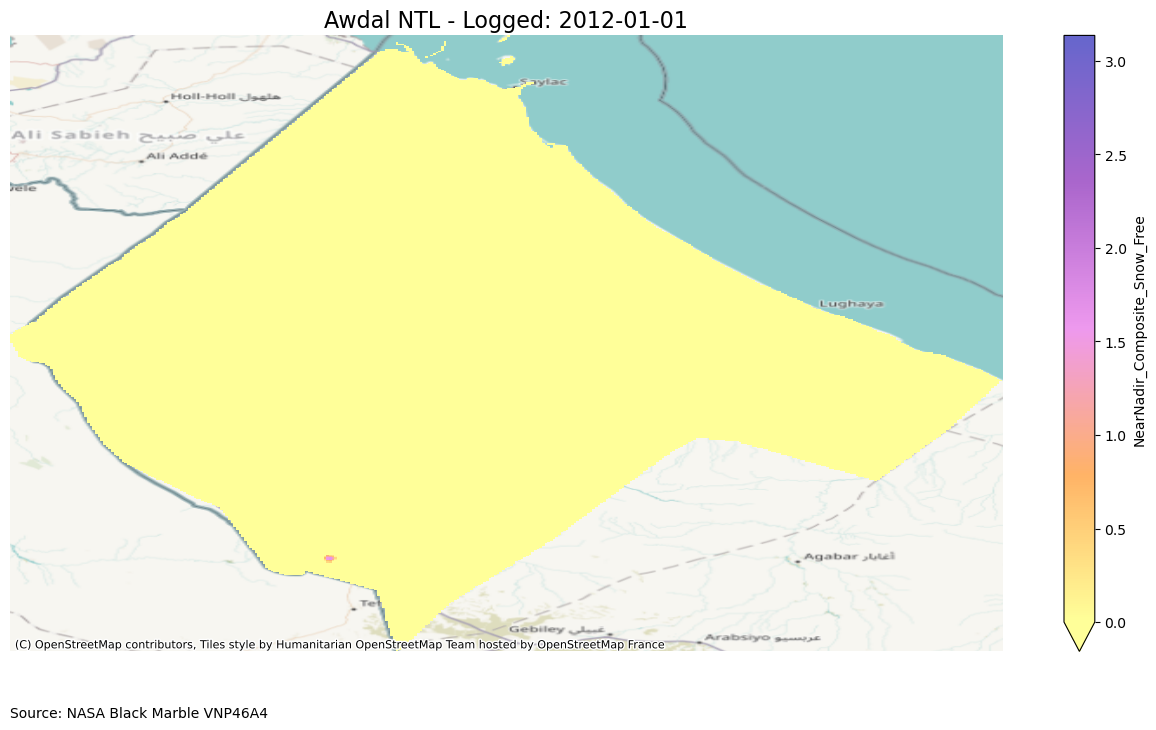

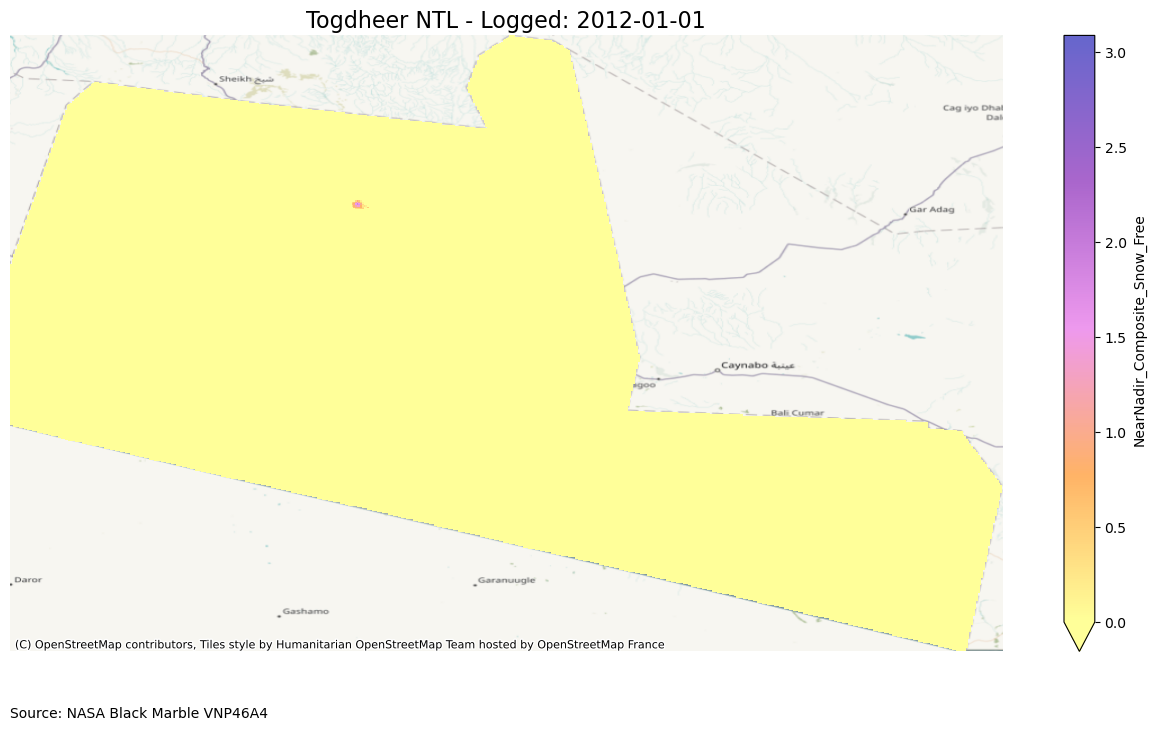

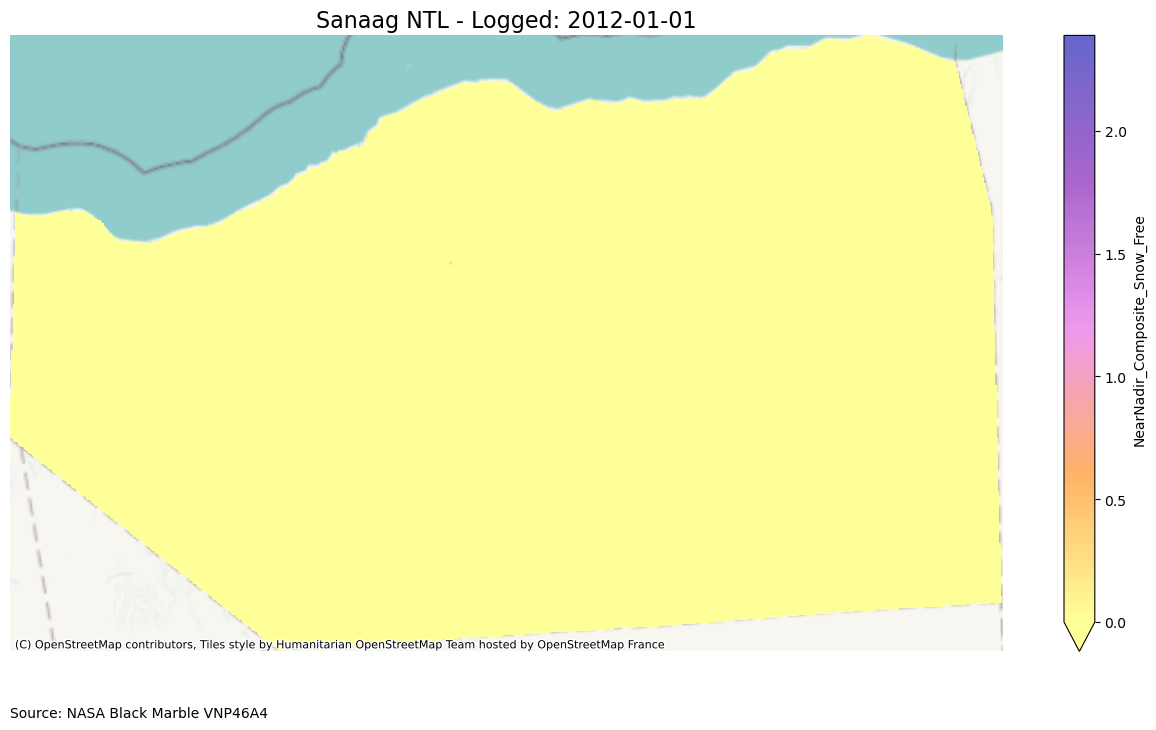

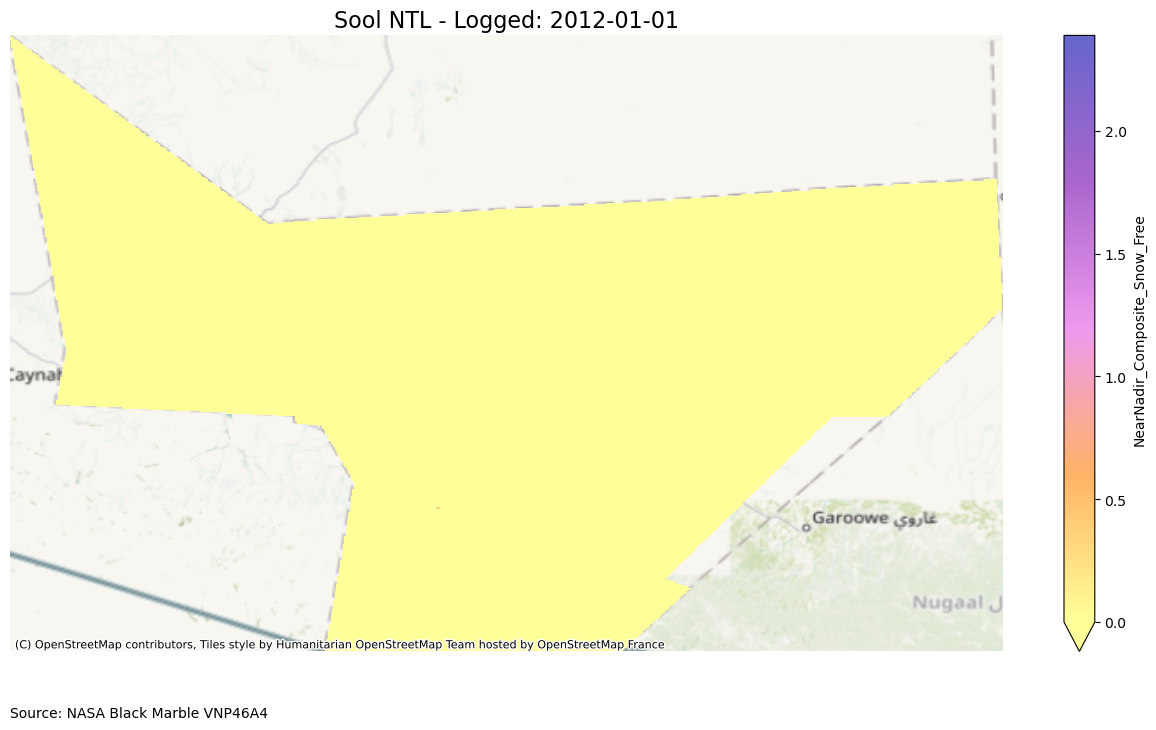

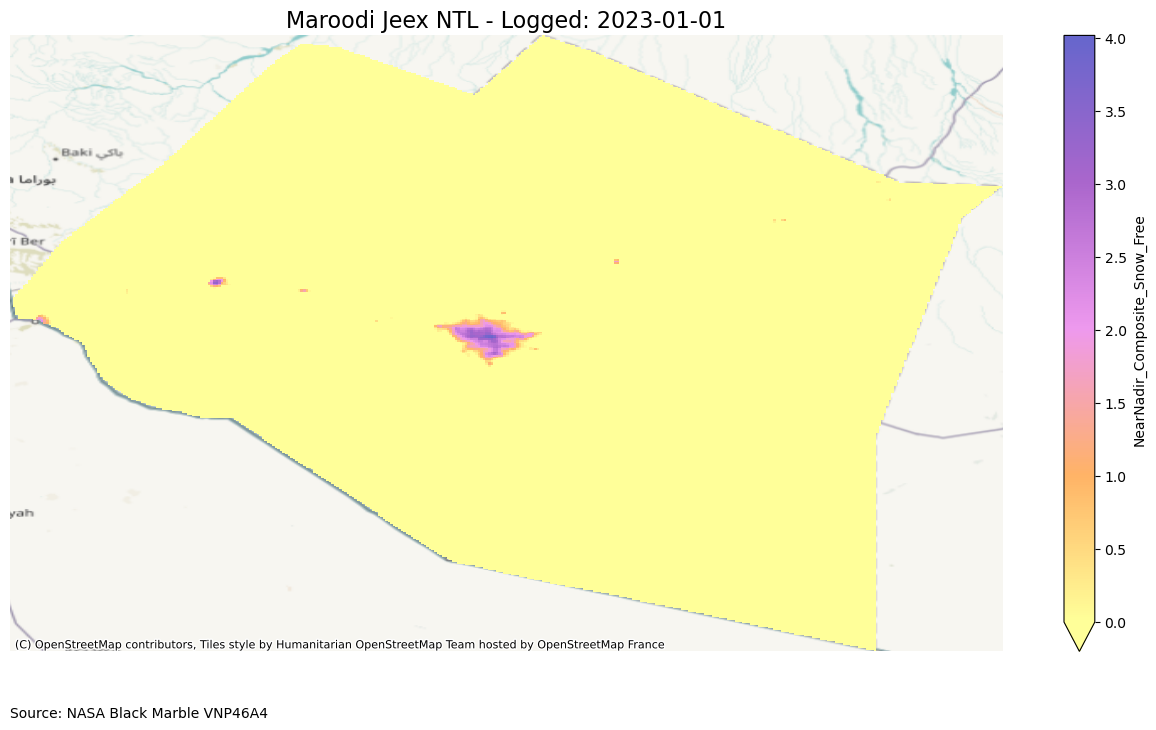

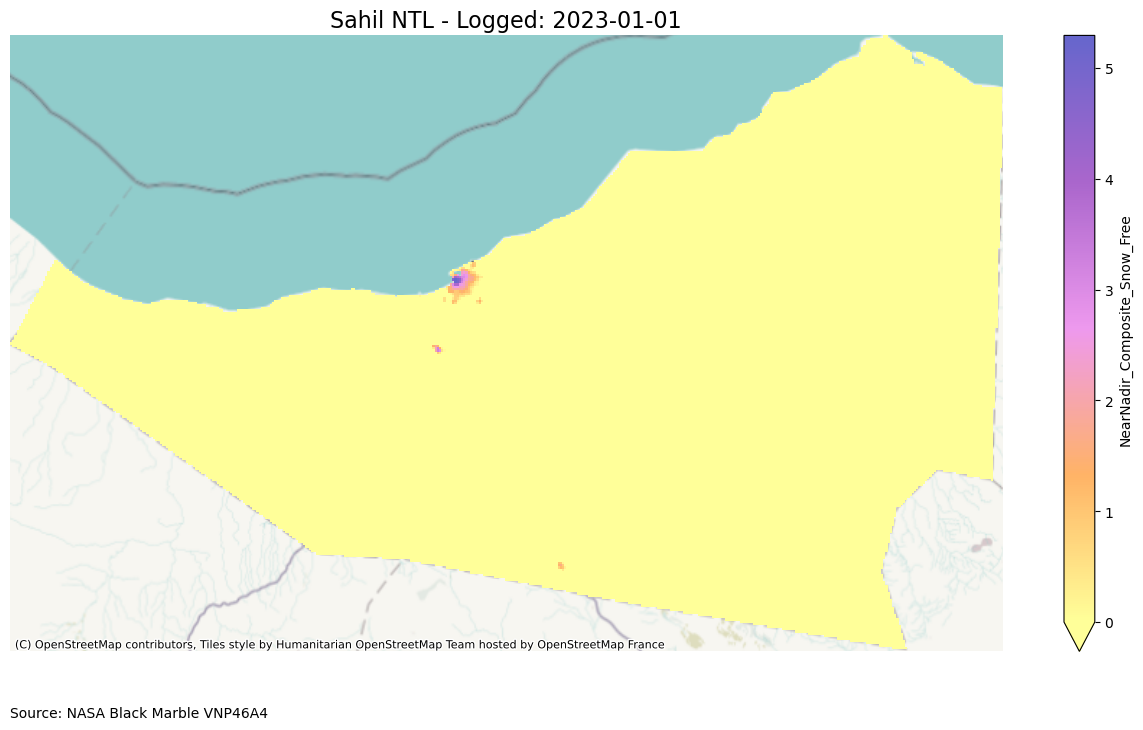

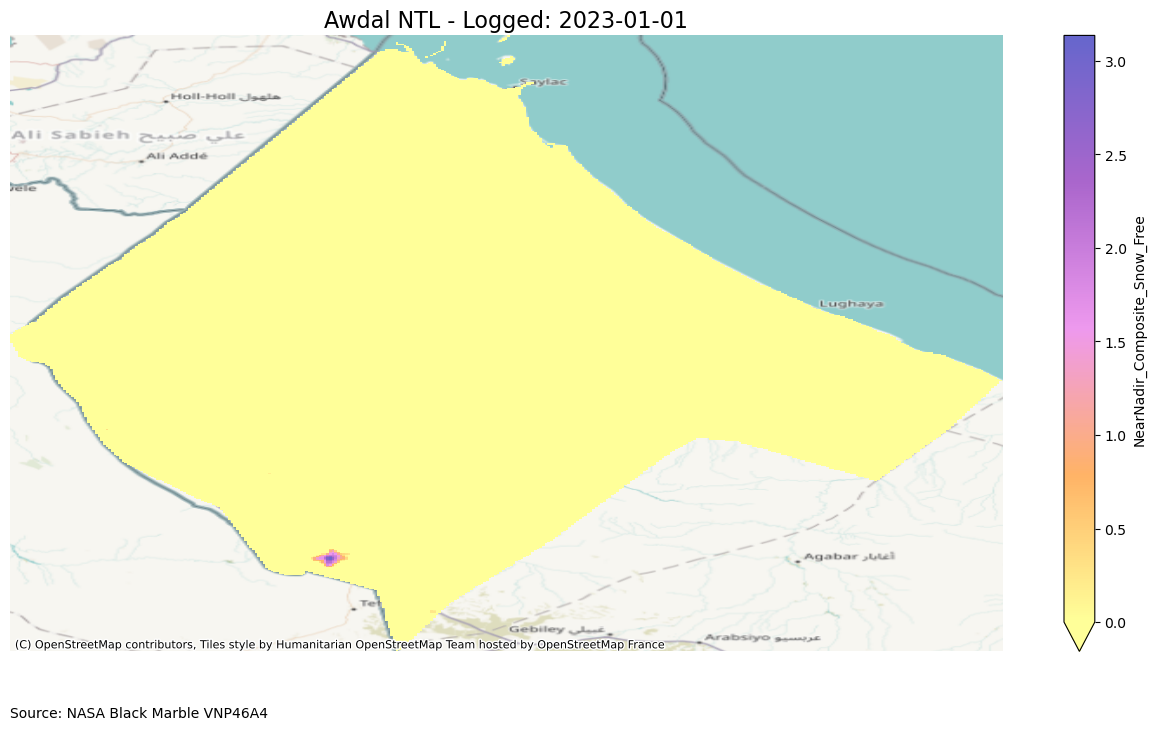

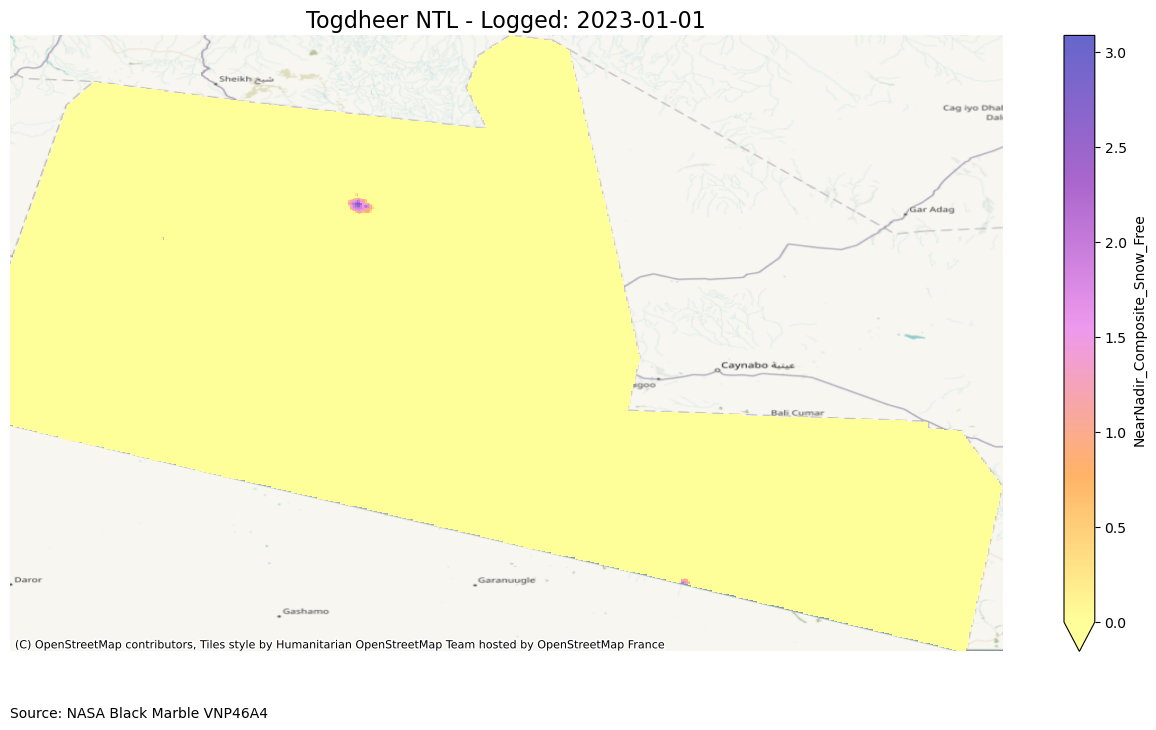

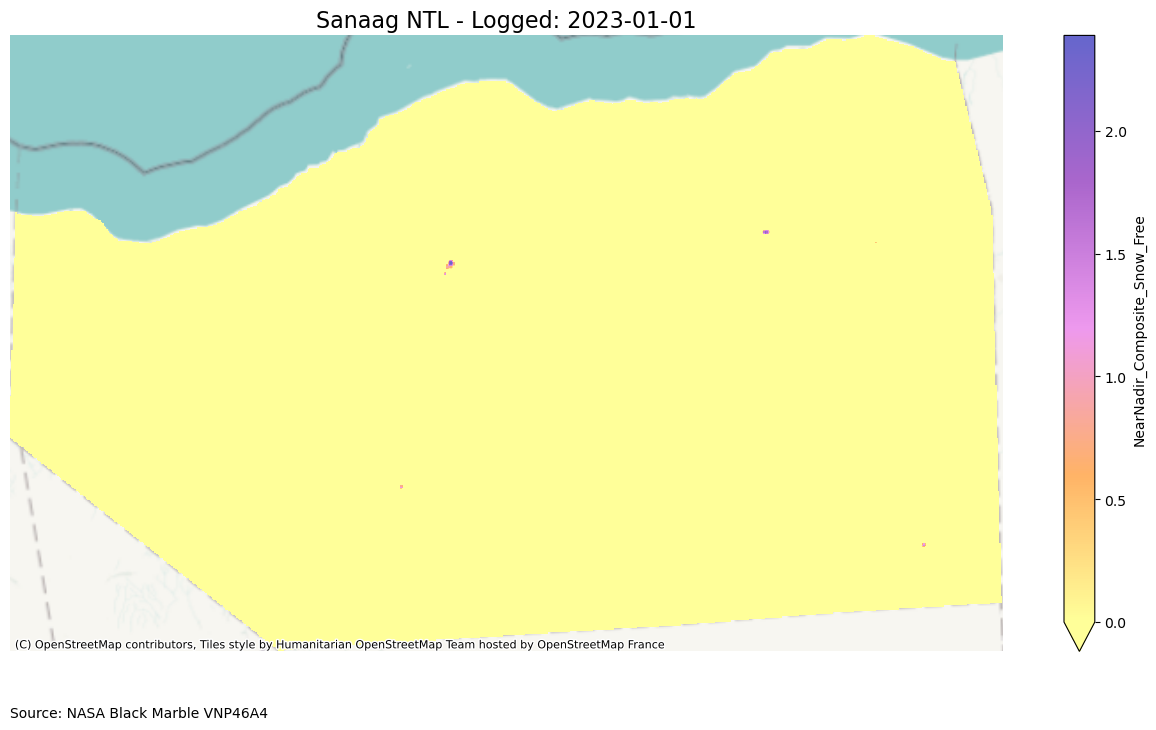

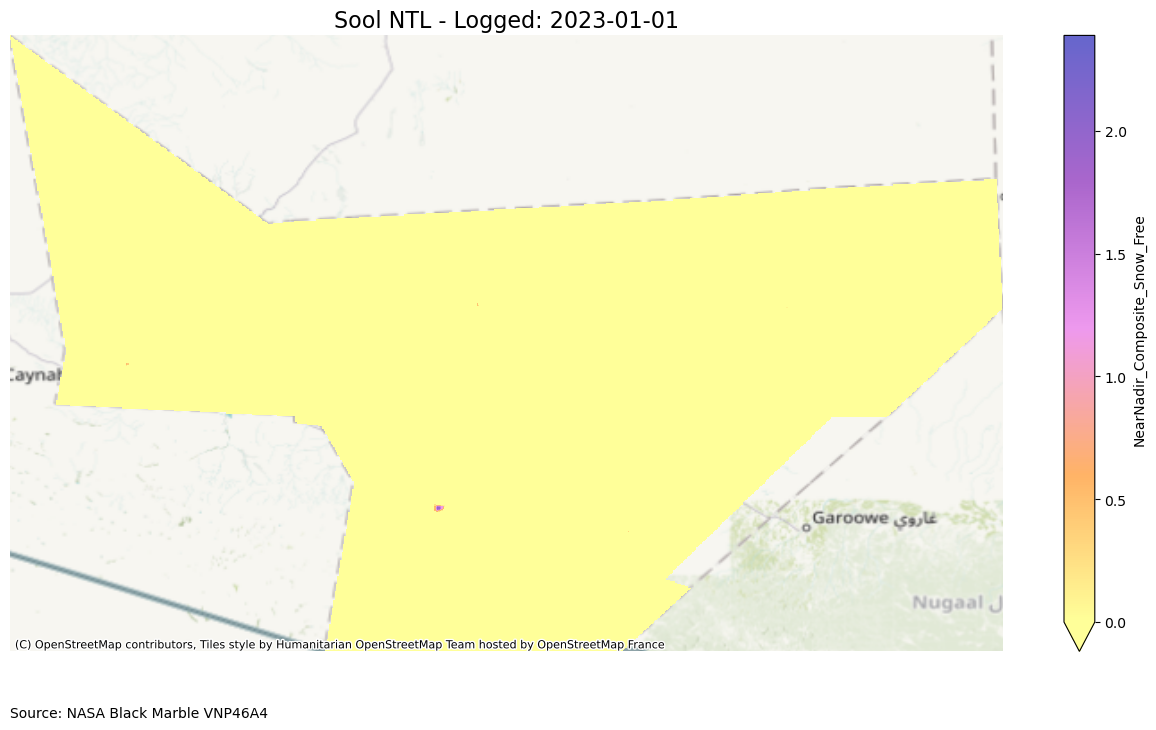

In [9]:
# 0 : "Maroodi Jeex",
# 1 : "Sahil",
# 2 : "Awdal",
# 3 : "Togdheer",
# 4 : "Sanaag",
# 5 : "Sool"

for year in [2012, 2023]:
    for i in range(0,6):
        region = list(log_region_list.keys())[i]
        data = log_region_list[region]
        plot_NASA_NTL(data, somaliland_shp[somaliland_shp["admin1Name"]==f"{region}"], date = f"{year}-01-01", 
                      variable = "NearNadir_Composite_Snow_Free",
                      title_prefix = f"{region} NTL - Logged", cmap=NTL_cmap,
                      robust = False, vmin=0, vmax = data["NearNadir_Composite_Snow_Free"].max())
        #plt.savefig(f'../output/Graphics/{region}_{year}.png', dpi=300, bbox_inches='tight')  

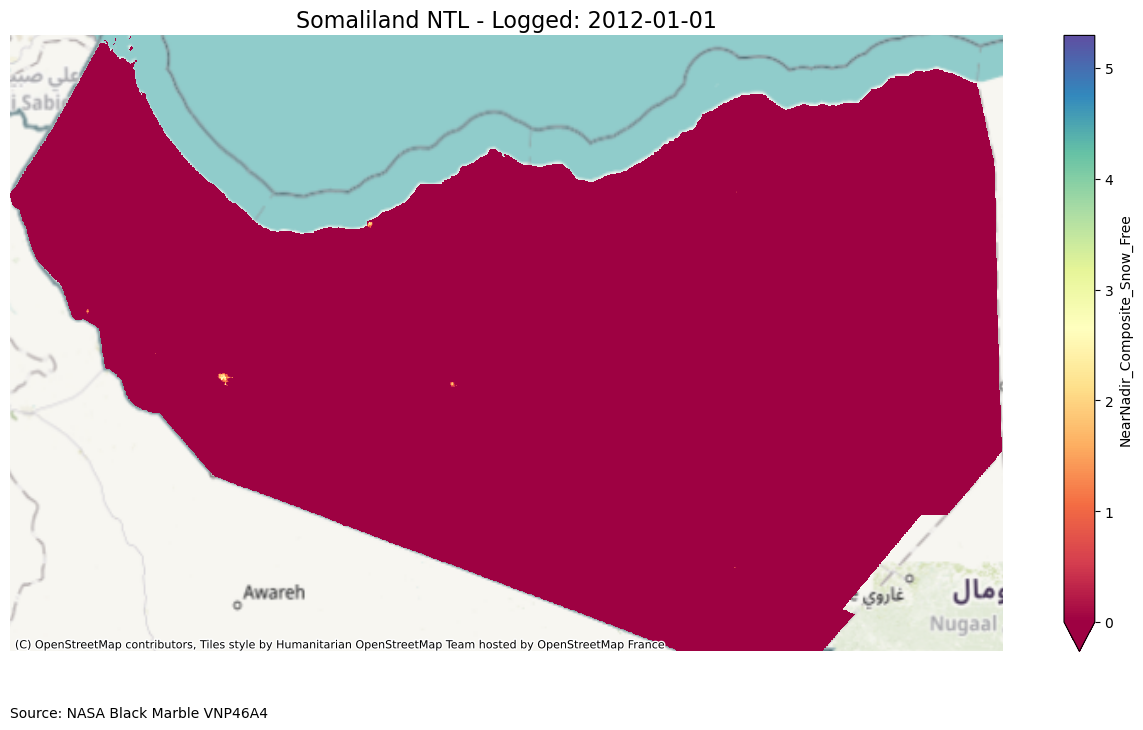

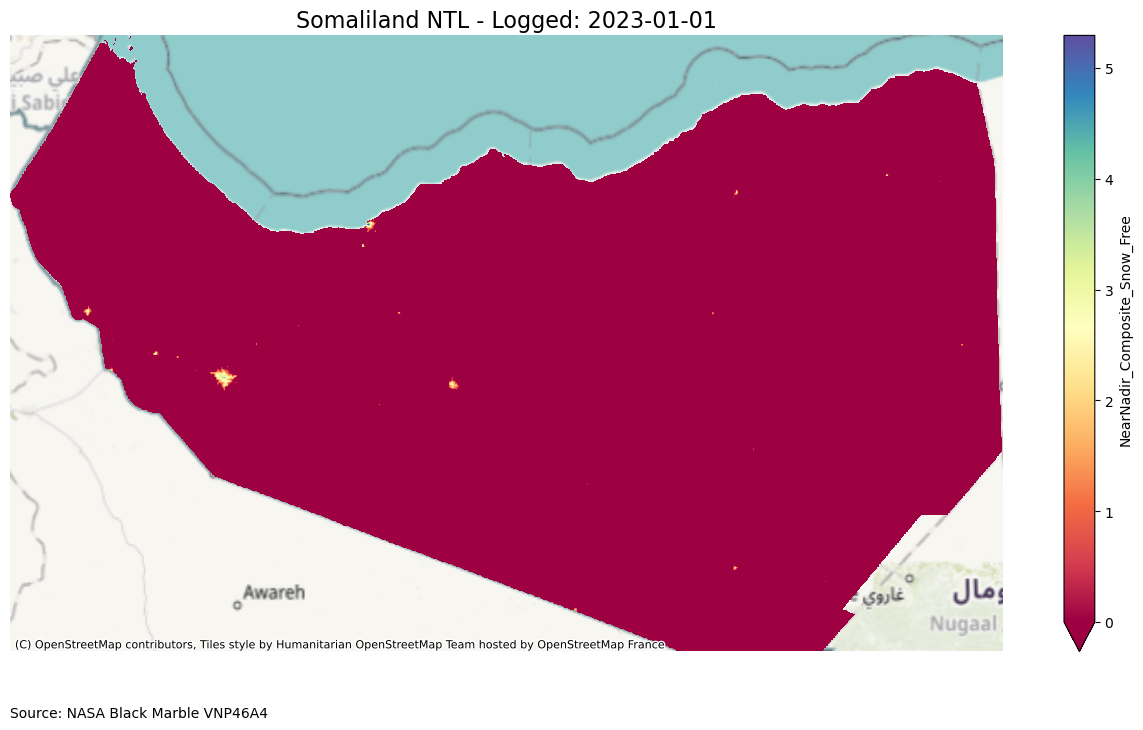

In [10]:
for year in [2012,2023]:
    plot_NASA_NTL(logged_NTL, somaliland_shp, date = f"{year}-01-01", 
                    variable = "NearNadir_Composite_Snow_Free",
                    title_prefix = "Somaliland NTL - Logged",
                    cmap="Spectral",
                    robust = False, vmin=0, vmax = logged_NTL["NearNadir_Composite_Snow_Free"].max())
    #plt.savefig(f'../output/Graphics/{region}_{year}.png', dpi=300, bbox_inches='tight')  

In [11]:
all_region_yearly_pixels = {}

for region_name, region_data in zip(region_names, region_datasets):
    yearly_pixels = []
    for year in range(2012, 2024):
        try:
            value = (region_data["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01") > 0).sum().item()
        except KeyError:
            value = np.nan  # If the date is missing
        yearly_pixels.append(round(value, 1))
    all_region_yearly_pixels[region_name] = yearly_pixels


regions_pixels = pd.DataFrame(all_region_yearly_pixels)
regions_pixels["Year"] = list(range(2012, 2024))
regions_pixels = regions_pixels[["Year"] + region_names]

regions_pixels["Total"] = regions_pixels[region_names].sum(axis=1)

total = []
for year in range(2012, 2024):
        try:
            value = (SL_Berbera_VNP46A4_EY_2012_24["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01") > 0).sum().item()
        except KeyError:
            value = np.nan  # If the date is missing
        total.append(round(value, 1))
#total

In [12]:
growth_rate_radiance = {}

for i in regions.columns[1:]:
    yearly_growth = []
    for year in range(1, len(regions["Total"])):
        try: 
            value = (((regions[i][year]-regions[i][year-1])/regions[i][year-1])*100)
        except:
            value = np.nan
        yearly_growth.append(round(value,1))
    growth_rate_radiance[i] = yearly_growth

growth_rate_radiance = pd.DataFrame(growth_rate_radiance)
growth_rate_radiance["Year"] = list(range(2013, 2024))
growth_rate_radiance = growth_rate_radiance[["Year"] + region_names]

In [13]:
growth_rate_radiance = []
growth_rate_pixels = []
for i in range(1, len(regions["Total"])):
    grr = (((regions["Total"][i]-regions["Total"][i-1])/regions["Total"][i-1])*100)
    grp = (((regions_pixels["Total"][i]-regions_pixels["Total"][i-1])/regions_pixels["Total"][i-1])*100)
    growth_rate_radiance.append(round(grr,2))
    growth_rate_pixels.append(round(grp,2))

growth_rate = pd.DataFrame(list(range(2013, 2024)), columns=["Year"])
growth_rate["Pixel Growth Rate"] = growth_rate_pixels
growth_rate["Radiance Growth Rate"] = growth_rate_radiance


In [14]:
regions_pixels

,Year,Maroodi Jeex,Sahil,Awdal,Togdheer,Sanaag,Sool,Total
0,2012,347,72,43,94,14,13,583
1,2013,360,79,50,90,10,33,622
2,2014,420,92,46,108,32,43,741
3,2015,474,86,50,107,16,43,776
4,2016,491,87,50,111,19,42,800
5,2017,568,103,67,142,32,45,957
6,2018,643,146,86,179,40,48,1142
7,2019,670,132,84,193,121,51,1251
8,2020,753,151,110,206,53,57,1330
9,2021,924,205,144,239,90,88,1690


In [15]:
cities

,Year,Hargeisa,Berbera,Boroma,Burao,Erigavo,Las Anod,Total Cities
0,2012,1066.2,220.1,70.0,146.6,10.2,11.3,1524.4
1,2013,1103.3,267.9,102.6,154.6,8.4,48.3,1685.1
2,2014,1235.4,242.9,92.6,168.3,13.8,68.8,1821.8
3,2015,1375.2,261.6,94.1,170.8,14.3,67.0,1983.0
4,2016,1474.8,283.0,88.3,187.6,15.3,81.3,2130.3
5,2017,1721.3,305.3,116.8,233.9,16.1,84.9,2478.3
6,2018,2112.7,498.6,158.1,294.4,23.8,84.4,3172.0
7,2019,2498.6,570.8,199.4,407.7,36.2,98.3,3811.0
8,2020,3119.3,746.2,288.8,491.5,55.3,128.5,4829.6
9,2021,3935.2,1282.4,428.1,617.1,90.0,159.7,6512.5


In [16]:
regions

,Year,Maroodi Jeex,Sahil,Awdal,Togdheer,Sanaag,Sool,Total
0,2012,1083.1,220.9,70.0,148.7,12.4,11.3,1546.4
1,2013,1129.1,268.5,102.6,156.5,8.4,48.3,1713.4
2,2014,1267.3,245.4,92.6,172.4,24.2,68.8,1870.7
3,2015,1423.8,265.5,94.1,174.1,14.8,67.0,2039.3
4,2016,1546.0,285.8,88.8,191.3,18.8,81.3,2212.0
5,2017,1813.1,309.4,118.3,242.0,35.7,84.9,2603.4
6,2018,2241.3,507.2,158.6,317.9,45.4,84.4,3354.8
7,2019,2679.4,577.8,199.4,443.0,108.2,99.8,4107.6
8,2020,3408.0,756.6,290.4,547.2,81.3,133.2,5216.7
9,2021,4375.8,1303.1,435.6,699.3,172.1,186.8,7172.7


In [25]:
percentage_region_total

,Year,Maroodi Jeex,Sahil,Awdal,Togdheer,Sanaag,Sool
0,2012,70.0,14.3,4.5,9.6,0.8,0.7
1,2013,65.9,15.7,6.0,9.1,0.5,2.8
2,2014,67.7,13.1,5.0,9.2,1.3,3.7
3,2015,69.8,13.0,4.6,8.5,0.7,3.3
4,2016,69.9,12.9,4.0,8.6,0.8,3.7
5,2017,69.6,11.9,4.5,9.3,1.4,3.3
6,2018,66.8,15.1,4.7,9.5,1.4,2.5
7,2019,65.2,14.1,4.9,10.8,2.6,2.4
8,2020,65.3,14.5,5.6,10.5,1.6,2.6
9,2021,61.0,18.2,6.1,9.7,2.4,2.6


In [17]:
percentage_city_region

,Year,Maroodi Jeex,Sahil,Awdal,Togdheer,Sanaag,Sool,Total
0,2012,98.4,99.6,100.0,98.6,82.3,100.0,98.6
1,2013,97.7,99.8,100.0,98.8,100.0,100.0,98.3
2,2014,97.5,99.0,100.0,97.6,57.0,100.0,97.4
3,2015,96.6,98.5,100.0,98.1,96.6,100.0,97.2
4,2016,95.4,99.0,99.4,98.1,81.4,100.0,96.3
5,2017,94.9,98.7,98.7,96.7,45.1,100.0,95.2
6,2018,94.3,98.3,99.7,92.6,52.4,100.0,94.6
7,2019,93.3,98.8,100.0,92.0,33.5,98.5,92.8
8,2020,91.5,98.6,99.4,89.8,68.0,96.5,92.6
9,2021,89.9,98.4,98.3,88.2,52.3,85.5,90.8


In [18]:
growth_rate

,Year,Pixel Growth Rate,Radiance Growth Rate
0,2013,6.69,10.80
1,2014,19.13,9.18
2,2015,4.72,9.01
3,2016,3.09,8.47
4,2017,19.62,17.69
5,2018,19.33,28.86
6,2019,9.54,22.44
7,2020,6.31,27.00
8,2021,27.07,37.49
9,2022,34.73,23.77


In [19]:
growth_rate_radiance

[10.8, 9.18, 9.01, 8.47, 17.69, 28.86, 22.44, 27.0, 37.49, 23.77, 10.76]

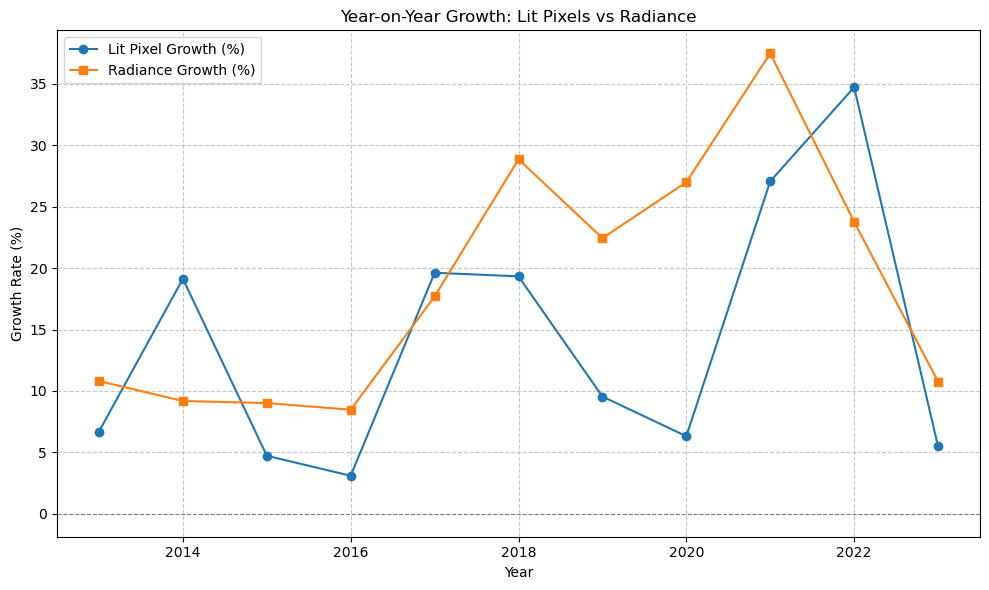

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(growth_rate['Year'], growth_rate['Pixel Growth Rate'], marker='o', label='Lit Pixel Growth (%)')
plt.plot(growth_rate['Year'], growth_rate['Radiance Growth Rate'], marker='s', label='Radiance Growth (%)')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Year-on-Year Growth: Lit Pixels vs Radiance')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
